In [1]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression


In [2]:
df = pd.read_csv(r"C:\Users\txxja\Desktop\datasets\creditcard.csv")

In [3]:
df.shape

(284807, 31)

In [4]:
df.sample(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
208324,137069.0,0.049672,1.141998,-1.180081,-0.348765,0.856607,-1.001382,1.061186,0.075560,-0.779363,...,0.316030,0.976794,-0.256196,-0.273434,-0.006798,-0.121362,-0.052690,-0.017140,4.59,0
208290,137051.0,1.975530,-0.387503,-0.380248,0.291827,-0.450982,-0.004531,-0.655279,0.061820,1.104537,...,0.221946,0.921220,0.041342,-0.442531,-0.030926,-0.205690,0.044239,-0.050150,4.99,0
109568,71439.0,1.268463,-0.786243,1.260457,-0.563567,-1.610362,-0.303796,-1.148641,0.104768,-0.489824,...,0.239571,0.690401,-0.015825,0.577500,0.286843,-0.235163,0.045698,0.023758,26.00,0
209548,137611.0,-1.217600,0.169544,0.539520,-1.625235,0.037430,-0.640584,0.431091,0.291254,-2.215154,...,-0.005384,0.038357,-0.362457,-0.301395,0.811345,0.907038,-0.184808,-0.091291,73.75,0
149079,90564.0,-0.150583,1.184321,-0.317141,-0.474391,0.898320,-0.494645,0.695933,0.031290,1.291027,...,-0.469165,-0.956312,0.132176,0.513642,-0.484476,0.061599,0.301913,0.123324,6.26,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df['Class'].value_counts()


Class
0    284315
1       492
Name: count, dtype: int64

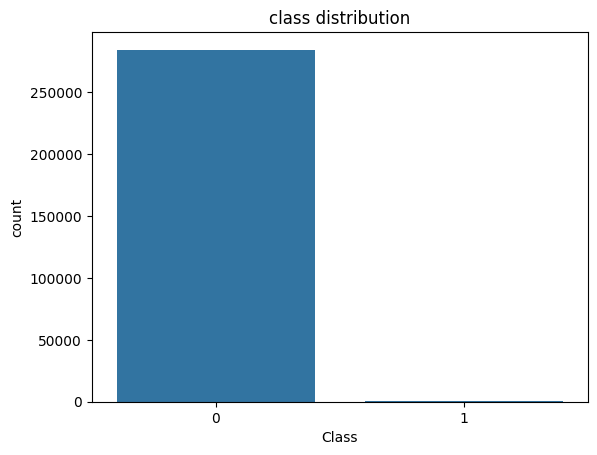

In [7]:
sns.countplot(x="Class",data=df)
plt.title("class distribution")
plt.show()

In [8]:
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

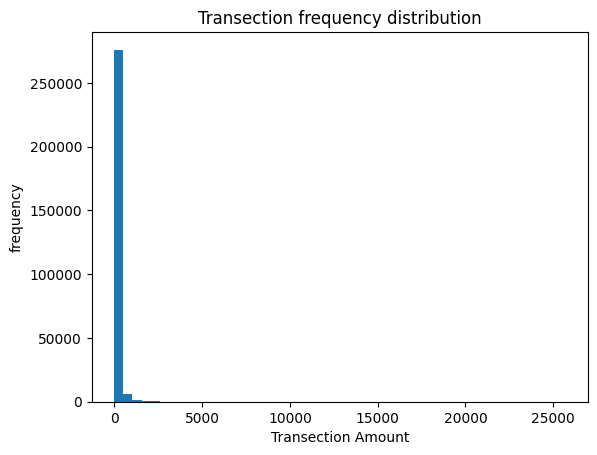

In [9]:
plt.hist(df["Amount"],bins=50)
plt.xlabel("Transection Amount")
plt.ylabel("frequency")
plt.title("Transection frequency distribution")
plt.show()

In [10]:
dx=df.drop(columns=["Class"])
dy=df["Class"]

In [11]:
dy.head(5)

0    0
1    0
2    0
3    0
4    0
Name: Class, dtype: int64

In [12]:
scaler=StandardScaler()
dx["Amount"]=scaler.fit_transform(dx[["Amount"]])

In [13]:
x_train,x_test,y_train,y_test=train_test_split(dx,dy,test_size=0.2)

In [14]:
lr=LogisticRegression(max_iter=3000,class_weight='balanced')
lr.fit(x_train,y_train)

C:\Users\txxja\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


In [15]:
dy_pred_lr=lr.predict(x_test)


In [16]:
dy_pred_lr

array([0, 0, 0, ..., 0, 0, 0], shape=(56962,))

In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test,dy_pred_lr))


              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56859
           1       0.06      0.93      0.12       103

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [18]:
from sklearn.metrics import roc_auc_score

In [19]:
print("ROC-AUC Score:", roc_auc_score(y_test, dy_pred_lr))

ROC-AUC Score: 0.9537522302230504


In [20]:
dy_prob_lr = lr.predict_proba(x_test)[:, 1]


In [21]:
y_prob_lr = lr.predict_proba(x_test)[:, 1]

print("ROC-AUC Score:", roc_auc_score(y_test, dy_prob_lr))


ROC-AUC Score: 0.9851799981456428


In [22]:
###### random forest

In [23]:
from sklearn.ensemble import RandomForestClassifier

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

In [25]:
rf.fit(x_train, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
y_pred_rf=rf.predict(x_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56859
           1       0.93      0.84      0.88       103

    accuracy                           1.00     56962
   macro avg       0.96      0.92      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [27]:
from sklearn.metrics import roc_auc_score
y_prob_rf = rf.predict_proba(x_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

ROC-AUC: 0.9748967681423489


In [28]:
from sklearn.metrics import classification_report
import numpy as np

In [29]:
y_pred_rf = rf.predict_proba(x_test)[:, 1]
y_pred_rf_5 = (y_pred_rf >= 0.3).astype(int)
print(classification_report(y_test, y_pred_rf_5))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56859
           1       0.80      0.86      0.83       103

    accuracy                           1.00     56962
   macro avg       0.90      0.93      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [30]:
#for t in [0.25, 0.2, 0.15, 0.1]:
#   y_pred = (y_pred_rf >= t).astype(int)
#   print(f"\nThreshold: {t}")
#   print(classification_report(y_test, y_pred))
#for threshold =0.1 its come near 0.91%


In [31]:
# Select real samples
fraud_sample = df[df["Class"] == 1].iloc[0]
normal_sample = df[df["Class"] == 0].iloc[0]

# Drop target column
fraud_values = fraud_sample.drop("Class").values
normal_values = normal_sample.drop("Class").values

import joblib
joblib.dump(fraud_values, "fraud_sample.pkl")
joblib.dump(normal_values, "normal_sample.pkl")


['normal_sample.pkl']